## 🏡 House Prices Prediction — ML Project

В данном проекте решается задача предсказания стоимости жилой недвижимости на основе датасета [**House Price Data, England & Wales, 1995 to 2019**](https://www.kaggle.com/datasets/dmaso01dsta/house-price-data-england-wales-1995-to-2019/). Мы выбрали из датасета файл 2019 года

В рамках проекта рассматриваются две постановки задачи:

* **Регрессия** — предсказание точной стоимости дома (`Price`)
* **Классификация** — разбиение домов на категории (дешёвые, средние, дорогие)

---

**План:**
1. Анализ данных (EDA)
2. Предобработка данных
3. Feature Engineering
4. Подготовка данных для моделей

---

### 1. Анализ данных (EDA)

In [64]:
# Импорты библиотек и настройка окружения notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.2f}'.format)

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [65]:
# Загрузка датасета
df = pd.read_csv('../data/pp-2019.csv', header=None)

# 
df.columns = [
    'Transaction unique identifier', 'Price', 'Date of Transfer',
    'Postcode', 'Property Type', 'Old/New', 'Duration',
    'PAON', 'SAON', 'Street', 'Locality',
    'Town/City', 'District', 'County',
    'PPD Category Type', 'Record Status'
]

df['Date of Transfer'] = pd.to_datetime(df['Date of Transfer'], format='%Y-%m-%d %H:%M')

print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")

Строк: 864835, Столбцов: 16


In [66]:
# Типы данных и заполненность
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 864835 entries, 0 to 864834
Data columns (total 16 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Transaction unique identifier  864835 non-null  str           
 1   Price                          864835 non-null  int64         
 2   Date of Transfer               864835 non-null  datetime64[us]
 3   Postcode                       860780 non-null  str           
 4   Property Type                  864835 non-null  str           
 5   Old/New                        864835 non-null  str           
 6   Duration                       864835 non-null  str           
 7   PAON                           864835 non-null  str           
 8   SAON                           106850 non-null  str           
 9   Street                         849709 non-null  str           
 10  Locality                       328698 non-null  str           
 11  Town/City  

In [67]:
# Базовая статистика по Price
print("Базовая статистика:")
df.describe()

Базовая статистика:


,Price,Date of Transfer
count,864835.00,864835
mean,351500.29,2019-06-23 18:52:12.547595
min,1.00,2019-01-01 00:00:00
25%,148000.00,2019-03-29 00:00:00
50%,230000.00,2019-06-28 00:00:00
75%,355000.00,2019-09-13 00:00:00
max,542540820.00,2019-12-26 00:00:00
std,1997712.75,NaN


std очень высокое — значительный разброс и наличие выбросов. min = 1.00 — явный выброс.

In [68]:
print("Пропуски по столбцам:")
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)

Пропуски по столбцам:


SAON        757985
Locality    536137
Street       15126
Postcode      4055
District       182
dtype: int64

In [69]:
# Дубликаты (без UUID)
df_dup = df.drop(columns=['Transaction unique identifier'])
print(f"Дубликатов: {df_dup.duplicated().sum()}")

Дубликатов: 560


In [70]:
# Уникальные значения категориальных признаков
cat_cols = ['Property Type', 'Old/New', 'Duration', 'PPD Category Type', 'Record Status']
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

Property Type: <StringArray>
['T', 'S', 'D', 'F', 'O']
Length: 5, dtype: str
Old/New: <StringArray>
['N', 'Y']
Length: 2, dtype: str
Duration: <StringArray>
['F', 'L']
Length: 2, dtype: str
PPD Category Type: <StringArray>
['A', 'B']
Length: 2, dtype: str
Record Status: <StringArray>
['A']
Length: 1, dtype: str


В колонке Record Status представлена только одна категория, а значит это колонка не информативна

**Расшифровка категориальных признаков:**

- **Property Type**: D = Detached, S = Semi-Detached, T = Terraced, F = Flats/Maisonettes, O = Other
- **Old/New**: Y = новостройка, N = вторичный рынок
- **Duration**: F = Freehold (полное владение), L = Leasehold (долгосрочная аренда)
- **PPD Category Type**: A = стандартная сделка, B = дополнительный тип
- **Record Status**: A = Added, C = Changed, D = Deleted

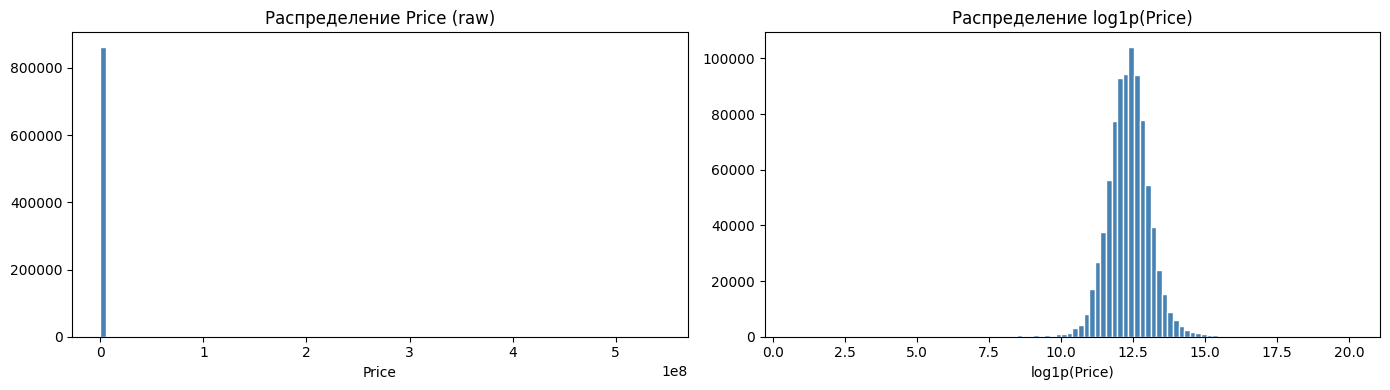

In [71]:
# Распределение цен (до удаления выбросов)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение Price (raw)')
axes[0].set_xlabel('Price')

axes[1].hist(np.log1p(df['Price']), bins=100, color='steelblue', edgecolor='white')
axes[1].set_title('Распределение log1p(Price)')
axes[1].set_xlabel('log1p(Price)')

plt.tight_layout()
plt.show()

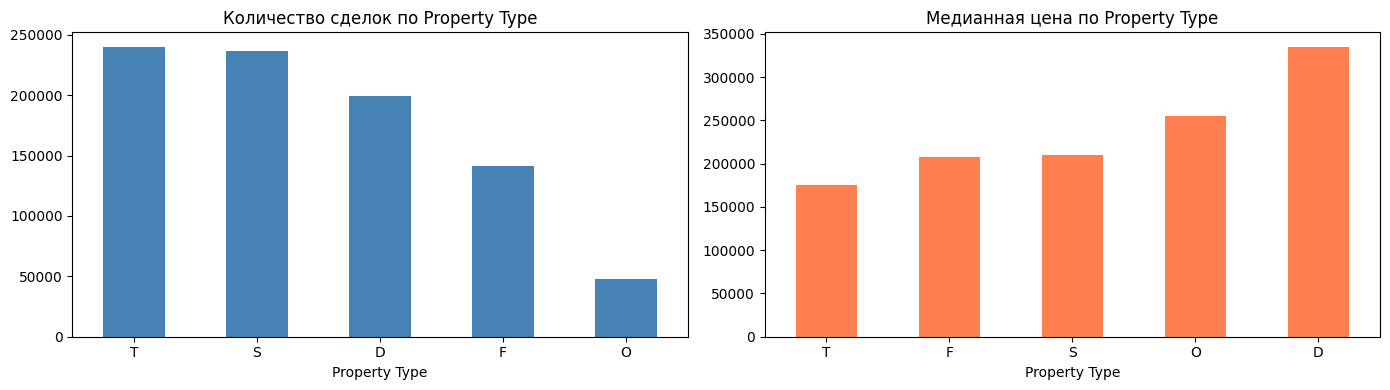

In [72]:
# Распределение по типу недвижимости
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['Property Type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Количество сделок по Property Type')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

df.groupby('Property Type')['Price'].median().sort_values().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Медианная цена по Property Type')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

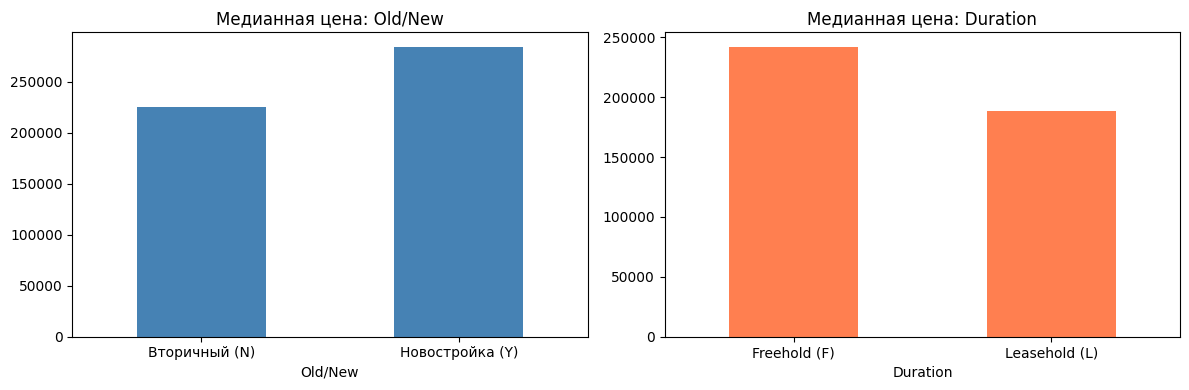

In [73]:
# Распределение по Old/New и Duration
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby('Old/New')['Price'].median().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Медианная цена: Old/New')
axes[0].set_xticklabels(['Вторичный (N)', 'Новостройка (Y)'], rotation=0)

df.groupby('Duration')['Price'].median().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Медианная цена: Duration')
axes[1].set_xticklabels(['Freehold (F)', 'Leasehold (L)'], rotation=0)

plt.tight_layout()
plt.show()

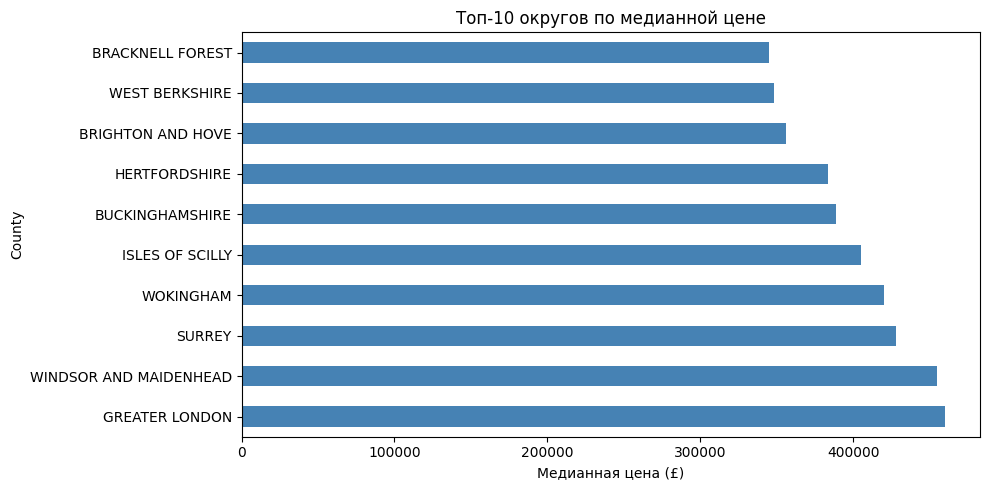

In [74]:
# Топ-10 округов по медианной цене
top_counties = df.groupby('County')['Price'].median().sort_values(ascending=False).head(10)
top_counties.plot(kind='barh', color='steelblue', figsize=(10, 5))
plt.title('Топ-10 округов по медианной цене')
plt.xlabel('Медианная цена (£)')
plt.tight_layout()
plt.show()

---

### 2. Предобработка данных

In [75]:
# Удаление дубликатов
print(f"До удаления дубликатов: {df.shape[0]} строк")
df = df.drop_duplicates(subset=df.columns.difference(['Transaction unique identifier']))
print(f"После удаления дубликатов: {df.shape[0]} строк")

До удаления дубликатов: 864835 строк
После удаления дубликатов: 864275 строк


In [76]:
# Удаление выбросов по Price
# Нижняя граница: 1000 (цены ниже нереальны для реального рынка)
# Верхняя граница: 99.9-й перцентиль
price_low = 1_000
price_high = df['Price'].quantile(0.999)

print(f"Верхняя граница (99.9%): £{price_high:,.0f}")
print(f"Строк до фильтрации: {df.shape[0]}")

df = df[(df['Price'] >= price_low) & (df['Price'] <= price_high)]
print(f"Строк после фильтрации: {df.shape[0]}")

Верхняя граница (99.9%): £12,500,000
Строк до фильтрации: 864275
Строк после фильтрации: 862701


In [77]:
# Удаляем тип 'O' (Other) — слишком малочисленная и неоднородная категория
print(f"Строк с Property Type = O: {(df['Property Type'] == 'O').sum()}")
df = df[df['Property Type'] != 'O']
print(f"Строк после удаления O: {df.shape[0]}")

Строк с Property Type = O: 45768
Строк после удаления O: 816933


In [78]:
# Фильтруем только стандартные сделки (PPD Category Type = A)
# Тип B — нестандартные сделки (аукционы, внутрисемейные переводы и т.д.)
print(f"PPD Category Type распределение:\n{df['PPD Category Type'].value_counts()}")
df = df[df['PPD Category Type'] == 'A']
print(f"Строк после фильтрации по PPD=A: {df.shape[0]}")

PPD Category Type распределение:
PPD Category Type
A    731704
B     85229
Name: count, dtype: int64
Строк после фильтрации по PPD=A: 731704


In [79]:
# Удаляем не информативную колонку:
df = df.drop(columns=['Record Status'])

In [80]:
# Обработка пропусков
# SAON (87% пропусков) — отсутствует у большинства объектов (есть только у квартир)
# Locality (62% пропусков) — необязательное поле
# Эти столбцы не используем в модели
print(f"До обработки пропусков: {df.shape}")
df = df.drop(columns=['SAON', 'Locality'])

# Street: заполняем 'Unknown' для редких пропусков
df['Street'] = df['Street'].fillna('Unknown')

# Postcode: строки без почтового индеса удаляем — без него нельзя определить регион
df = df.dropna(subset=['Postcode'])

# District: малое количество пропусков, просто удаляем записи с пропусками
df = df.dropna(subset=['District'])

print(f"После обработки пропусков: {df.shape}")
print("\nПропуски отсутсвуют:")
print(df.isnull().sum()[df.isnull().sum() > 0])

До обработки пропусков: (731704, 15)
После обработки пропусков: (731321, 13)

Пропуски отсутсвуют:
Series([], dtype: int64)


In [81]:
# Сброс индекса после всех фильтраций
df = df.reset_index(drop=True)
print(f"Итоговый размер: {df.shape}")

Итоговый размер: (731321, 13)


---

### 3. Feature Engineering

In [82]:
# Временные признаки из Date of Transfer
df['year'] = df['Date of Transfer'].dt.year
df['month'] = df['Date of Transfer'].dt.month
df['quarter'] = df['Date of Transfer'].dt.quarter

print(df[['Date of Transfer', 'year', 'month', 'quarter']].tail())

       Date of Transfer  year  month  quarter
731316       2019-08-16  2019      8        3
731317       2019-09-26  2019      9        3
731318       2019-05-22  2019      5        2
731319       2019-09-27  2019      9        3
731320       2019-10-04  2019     10        4


In [83]:
# Регион из Postcode — первая часть (outward code, например 'SS2', 'RM16')
df['postcode_area'] = df['Postcode'].str.extract(r'^([A-Z]+)')
df['postcode_district'] = df['Postcode'].str.split(' ').str[0]

print(df[['Postcode', 'postcode_area', 'postcode_district']].head())
df.info()

   Postcode postcode_area postcode_district
0   SS2 6ST            SS               SS2
1  RM16 2PT            RM              RM16
2   CM3 4BS            CM               CM3
3   SS3 9RJ            SS               SS3
4   CM3 4UR            CM               CM3
<class 'pandas.DataFrame'>
RangeIndex: 731321 entries, 0 to 731320
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Transaction unique identifier  731321 non-null  str           
 1   Price                          731321 non-null  int64         
 2   Date of Transfer               731321 non-null  datetime64[us]
 3   Postcode                       731321 non-null  str           
 4   Property Type                  731321 non-null  str           
 5   Old/New                        731321 non-null  str           
 6   Duration                       731321 non-null  str           
 7   PAON               

In [84]:
# Медианная цена по округу (County) — geographic price signal
county_median = df.groupby('County')['Price'].median()
df['county_median_price'] = df['County'].map(county_median)

# Медианная цена по postcode_district — более точный географический сигнал
district_median = df.groupby('postcode_district')['Price'].median()
df['postcode_district_median_price'] = df['postcode_district'].map(district_median)

print(df[['County', 'county_median_price', 'postcode_district', 'postcode_district_median_price']].head())

            County  county_median_price postcode_district  postcode_district_median_price
0  SOUTHEND-ON-SEA            290000.00               SS2                       260000.00
1         THURROCK            285000.00              RM16                       313300.00
2            ESSEX            310000.00               CM3                       375000.00
3  SOUTHEND-ON-SEA            290000.00               SS3                       300000.00
4            ESSEX            310000.00               CM3                       375000.00


In [85]:
# Флаг: новостройка
df['is_new'] = (df['Old/New'] == 'Y').astype(int)

# Флаг: freehold (полное владение)
df['is_freehold'] = (df['Duration'] == 'F').astype(int)

print(df[['Old/New', 'is_new', 'Duration', 'is_freehold']].head())

  Old/New  is_new Duration  is_freehold
0       N       0        F            1
1       N       0        F            1
2       N       0        F            1
3       N       0        F            1
4       N       0        F            1


In [86]:
# Проверяем корреляцию новых числовых признаков с Price
numeric_features = [
    'year', 'month', 'quarter',
    'county_median_price', 'postcode_district_median_price',
    'is_new', 'is_freehold'
]

corr = df[numeric_features + ['Price']].corr()['Price'].drop('Price').sort_values(key=abs, ascending=False)
print("Корреляция признаков с Price:")
print(corr)

Корреляция признаков с Price:
postcode_district_median_price   0.64
county_median_price              0.48
is_new                           0.06
is_freehold                      0.05
quarter                          0.02
month                            0.02
year                              NaN
Name: Price, dtype: float64


---

### 4. Подготовка данных для моделей

In [87]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

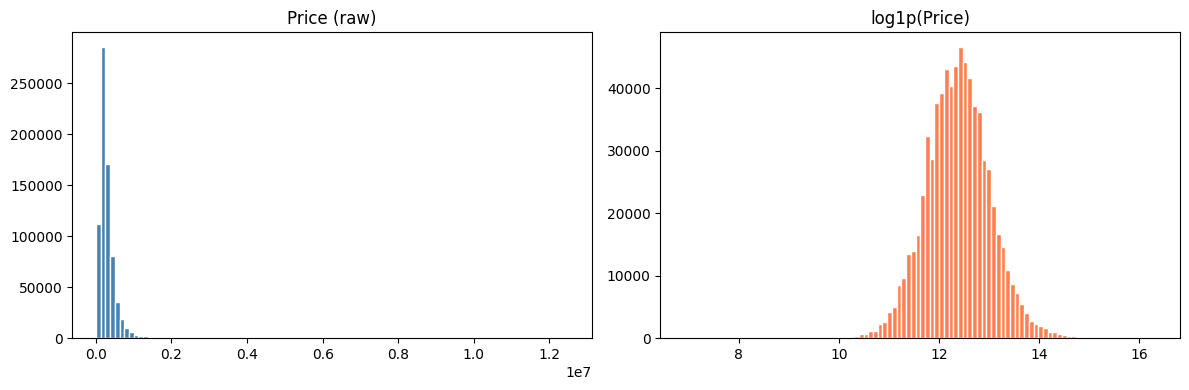

In [88]:
# Логарифмирование целевой переменной
# Price имеет сильно правостороннее распределение — log нормализует его
df['log_price'] = np.log1p(df['Price'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Price (raw)')
axes[1].hist(df['log_price'], bins=100, color='coral', edgecolor='white')
axes[1].set_title('log1p(Price)')
plt.tight_layout()
plt.show()

In [89]:
# Кодирование категориальных признаков — Label Encoding
# Используем для: Property Type, postcode_area, County, Town/City
# (высокая кардинальность — One-Hot даст слишком много признаков)

cat_encode_cols = ['Property Type', 'postcode_area', 'County', 'Town/City']

le_encoders = {}
for col in cat_encode_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    le_encoders[col] = le
    print(f"{col}: {df[col].nunique()} уникальных значений")

print(df['Town/City'].head())
df['Town/City_enc'].head()

Property Type: 4 уникальных значений
postcode_area: 106 уникальных значений
County: 113 уникальных значений
Town/City: 1144 уникальных значений
0    SOUTHEND-ON-SEA
1              GRAYS
2         CHELMSFORD
3    SOUTHEND-ON-SEA
4         CHELMSFORD
Name: Town/City, dtype: str


0    912
1    417
2    231
3    912
4    231
Name: Town/City_enc, dtype: int64

In [90]:
# Итоговый набор признаков для модели
feature_cols = [
    # Временные
    'year', 'month', 'quarter',
    # Закодированные категориальные
    'Property Type_enc', 'postcode_area_enc', 'County_enc', 'Town/City_enc',
    # Бинарные флаги
    'is_new', 'is_freehold',
    # Географические медианы
    'county_median_price', 'postcode_district_median_price',
]

X = df[feature_cols].copy()
y_reg = df['log_price'].copy()       # для регрессии

print(f"Размер X: {X.shape}")
print(f"Признаки: {feature_cols}")

Размер X: (731321, 11)
Признаки: ['year', 'month', 'quarter', 'Property Type_enc', 'postcode_area_enc', 'County_enc', 'Town/City_enc', 'is_new', 'is_freehold', 'county_median_price', 'postcode_district_median_price']


In [91]:
# Целевая переменная для классификации
# 3 класса: низкая (<25%), средняя (25–75%), высокая (>75%)
q25 = df['Price'].quantile(0.25)
q75 = df['Price'].quantile(0.75)

print(f"Граница низкая/средняя: £{q25:,.0f}")
print(f"Граница средняя/высокая: £{q75:,.0f}")

def price_class(price):
    if price < q25:
        return 0  # низкая
    elif price <= q75:
        return 1  # средняя
    else:
        return 2  # высокая

y_clf = df['Price'].apply(price_class)

print(f"\nРаспределение классов:")
print(y_clf.value_counts().sort_index().rename({0: 'Низкая', 1: 'Средняя', 2: 'Высокая'}))

Граница низкая/средняя: £155,000
Граница средняя/высокая: £356,000

Распределение классов:
Price
Низкая     178306
Средняя    370200
Высокая    182815
Name: count, dtype: int64


In [92]:
# Train/Test split — 80/20, стратификация для классификации
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Train: {X_train.shape[0]} строк")
print(f"Test:  {X_test.shape[0]} строк")

Train: 585056 строк
Test:  146265 строк


In [93]:
# Масштабирование (для линейных моделей)
# Fit только на train, transform на оба
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

print("Масштабирование выполнено.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")

Масштабирование выполнено.
X_train_scaled shape: (585056, 11)
X_test_scaled shape:  (146265, 11)


In [94]:
# Итоговый чеклист перед обучением
print("=" * 50)
print("ДАННЫЕ ГОТОВЫ К ОБУЧЕНИЮ")
print("=" * 50)
print(f"Признаков: {len(feature_cols)}")
print(f"Train размер: {X_train.shape[0]}")
print(f"Test  размер: {X_test.shape[0]}")
print(f"\nДоступны:")
print(f"  X_train, X_test           — без масштабирования (для деревьев)")
print(f"  X_train_scaled, X_test_scaled — масштабированные (для линейных моделей)")
print(f"  y_reg_train, y_reg_test   — log1p(Price) для регрессии")
print(f"  y_clf_train, y_clf_test   — 0/1/2 для классификации")

ДАННЫЕ ГОТОВЫ К ОБУЧЕНИЮ
Признаков: 11
Train размер: 585056
Test  размер: 146265

Доступны:
  X_train, X_test           — без масштабирования (для деревьев)
  X_train_scaled, X_test_scaled — масштабированные (для линейных моделей)
  y_reg_train, y_reg_test   — log1p(Price) для регрессии
  y_clf_train, y_clf_test   — 0/1/2 для классификации
